# Make BIDS Data

This notebook demonstrates the data-standardization layer of the tutorial. It generates five simulated subjects with the random model and writes them as a BIDS-compatible EEG dataset under `data/bids/`.

**Input:** simulation functions from `src/simulation/`.

**Output:** `data/bids/`, including `dataset_description.json`, `participants.tsv`, EEG sidecars, and channel metadata.

**Tutorial step:** Section 7.3, convert analysis data into a predictable BIDS structure.

---


## 1. Setup & Data Generation

In [1]:
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../utils'))

import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import mne_bids
from mne_bids import BIDSPath, read_raw_bids
import numpy as np

from simulation.simulation_models import simulate
from methods.convert_to_bids import init_dataset, write_subject, finalise_dataset


mne.set_log_level('WARNING')

# ── Parameters ────────────────────────────────────────────────────────────────
N_SUBJECTS  = 5
MODEL       = 'random'
T           = 10000         # time points per subject
FS          = 256           # Hz
CH_NAMES    = [f'x{i+1}' for i in range(5)]   # lowercase: x1-x5
TASK        = 'random'      # BIDS task label
BASE_SEED   = 42

REPO_ROOT = Path('..').resolve()
BIDS_ROOT = REPO_ROOT / 'data' / 'bids'

print(f'MNE        : {mne.__version__}')
print(f'MNE-BIDS   : {mne_bids.__version__}')
print(f'BIDS root  : {BIDS_ROOT}')

MNE        : 1.11.0
MNE-BIDS   : 0.18.0
BIDS root  : /home/jovyan/work/data/bids


In [2]:
# Generate one (5, 10000) signal per subject with a unique seed
subjects = {}
for i in range(N_SUBJECTS):
    seed = BASE_SEED + i
    subjects[f'{i+1:02d}'] = {
        'signal': simulate(MODEL, T=T, seed=seed),   # shape (5, 10000)
        'seed':   seed,
    }

print(f'Generated {N_SUBJECTS} subjects  |  model={MODEL}  |  shape={subjects["01"]["signal"].shape}')
for sub_id, info in subjects.items():
    s = info['signal']
    print(f'  sub-{sub_id}  seed={info["seed"]}  '
          f'range=[{s.min():.2f}, {s.max():.2f}]')

Generated 5 subjects  |  model=random  |  shape=(5, 10000)
  sub-01  seed=42  range=[-4.35, 4.31]
  sub-02  seed=43  range=[-3.70, 4.19]
  sub-03  seed=44  range=[-3.99, 3.78]
  sub-04  seed=45  range=[-4.22, 4.40]
  sub-05  seed=46  range=[-4.23, 4.25]


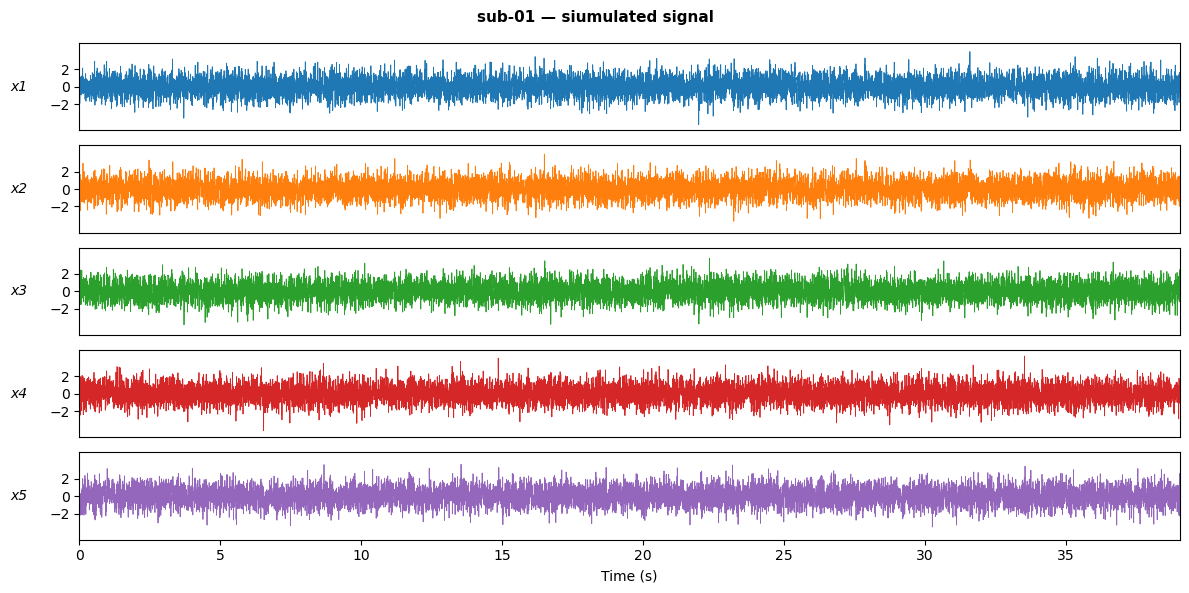

In [3]:
# Quick overview: Full signal for sub-01, size(5,10000)
t_full = np.arange(T) / FS
sig_01 = subjects['01']['signal']

fig, axes = plt.subplots(5, 1, figsize=(12.0, 6.0), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 0.45, 5))

for i, (ax, col) in enumerate(zip(axes, colors)):
    ax.plot(t_full, sig_01[i], color=col, linewidth=0.6)
    ax.set_ylabel(CH_NAMES[i], rotation=0, labelpad=22, va='center', fontsize=10, fontstyle='italic')
    ax.set_ylim(-5, 5)
    ax.set_yticks([-2, 0, 2])
    ax.tick_params(bottom=(i == 4))

axes[-1].set_xlabel('Time (s)', fontsize=10)
axes[-1].set_xlim(0, T / FS)
fig.suptitle('sub-01 — siumulated signal', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Write BIDS Dataset

Each simulated subject maps to one BIDS subject folder.  The (5 nodes × 1000
samples) array is stored as a BrainVision EEG file with five channels named
**x1–x5**.

In [4]:
# Remove any previous run so the dataset is rebuilt cleanly
if BIDS_ROOT.exists():
    shutil.rmtree(BIDS_ROOT)

# 1. Initialise dataset-level files
init_dataset(
    bids_root = BIDS_ROOT,
    name      = 'Simulated Effective Connectivity — Random Model',
    authors   = ['Hanwei Liu'],
    readme_extra = (
        'Ground truth: x1->x2 (delay=3), x1->x3 (delay=2), x4->x5 (delay=5).\n'
        'Nodes x1 and x4 are independent noise sources.'
    ),
)

# 2. Write each subject
bids_paths = {}
for sub_id, info in subjects.items():
    bp = write_subject(
        signal     = info['signal'],
        subject_id = sub_id,
        bids_root  = BIDS_ROOT,
        fs         = FS,
        ch_names   = CH_NAMES,
        task       = TASK,
    )
    bids_paths[sub_id] = bp
    print(f'  sub-{sub_id}  ->  {bp.fpath.name}')

print(f'\nDataset written to {BIDS_ROOT}')

/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: No events found or provided. Please add annotations to the raw data, or provide the events and event_id parameters. For resting state data, BIDS recommends naming the task using labels beginning with "rest".
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Converting data files to BrainVision format
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Encountered data in "double" format. Converting to float32.
  write_raw_bids(


  sub-01  ->  sub-01_task-random_eeg.json


/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: No events found or provided. Please add annotations to the raw data, or provide the events and event_id parameters. For resting state data, BIDS recommends naming the task using labels beginning with "rest".
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Converting data files to BrainVision format
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Encountered data in "double" format. Converting to float32.
  write_raw_bids(


  sub-02  ->  sub-02_task-random_eeg.json


/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: No events found or provided. Please add annotations to the raw data, or provide the events and event_id parameters. For resting state data, BIDS recommends naming the task using labels beginning with "rest".
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Converting data files to BrainVision format
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Encountered data in "double" format. Converting to float32.
  write_raw_bids(


  sub-03  ->  sub-03_task-random_eeg.json


/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: No events found or provided. Please add annotations to the raw data, or provide the events and event_id parameters. For resting state data, BIDS recommends naming the task using labels beginning with "rest".
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Converting data files to BrainVision format
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Encountered data in "double" format. Converting to float32.
  write_raw_bids(


  sub-04  ->  sub-04_task-random_eeg.json


/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: No events found or provided. Please add annotations to the raw data, or provide the events and event_id parameters. For resting state data, BIDS recommends naming the task using labels beginning with "rest".
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Converting data files to BrainVision format
  write_raw_bids(
/home/jovyan/work/src/methods/convert_to_bids.py:207: RuntimeWarning: Encountered data in "double" format. Converting to float32.
  write_raw_bids(


  sub-05  ->  sub-05_task-random_eeg.json

Dataset written to /home/jovyan/work/data/bids


## 3. Inspect Directory Structure

In [5]:
def print_tree(root: Path, indent: str = '', max_files: int = 6) -> None:
    entries = sorted(root.iterdir())
    dirs    = [e for e in entries if e.is_dir()]
    files   = [e for e in entries if e.is_file()]
    for f in files[:max_files]:
        print(f'{indent}|-- {f.name}')
    if len(files) > max_files:
        print(f'{indent}    ... ({len(files) - max_files} more files)')
    for d in dirs:
        print(f'{indent}+-- {d.name}/')
        print_tree(d, indent + '    ', max_files)

print(f'{BIDS_ROOT.name}/')
print_tree(BIDS_ROOT)

# File count summary
counts = {}
for p in BIDS_ROOT.rglob('*'):
    if p.is_file():
        counts[p.suffix] = counts.get(p.suffix, 0) + 1
print('\nFile counts:', {k: v for k, v in sorted(counts.items(), key=lambda x: -x[1])})

bids/
|-- README
|-- dataset_description.json
|-- participants.json
|-- participants.tsv
+-- sub-01/
    |-- sub-01_scans.tsv
    +-- eeg/
        |-- sub-01_task-random_channels.tsv
        |-- sub-01_task-random_eeg.eeg
        |-- sub-01_task-random_eeg.json
        |-- sub-01_task-random_eeg.vhdr
        |-- sub-01_task-random_eeg.vmrk
+-- sub-02/
    |-- sub-02_scans.tsv
    +-- eeg/
        |-- sub-02_task-random_channels.tsv
        |-- sub-02_task-random_eeg.eeg
        |-- sub-02_task-random_eeg.json
        |-- sub-02_task-random_eeg.vhdr
        |-- sub-02_task-random_eeg.vmrk
+-- sub-03/
    |-- sub-03_scans.tsv
    +-- eeg/
        |-- sub-03_task-random_channels.tsv
        |-- sub-03_task-random_eeg.eeg
        |-- sub-03_task-random_eeg.json
        |-- sub-03_task-random_eeg.vhdr
        |-- sub-03_task-random_eeg.vmrk
+-- sub-04/
    |-- sub-04_scans.tsv
    +-- eeg/
        |-- sub-04_task-random_channels.tsv
        |-- sub-04_task-random_eeg.eeg
        |-- sub-04_

In [6]:
import json

# Show the EEG sidecar JSON for sub-01
sidecar_path = bids_paths['01'].update(extension='.json').fpath
sidecar = json.loads(Path(sidecar_path).read_text(encoding='utf-8'))

print('sub-01 EEG sidecar (task-random_eeg.json):')
print('-' * 45)
for k, v in sidecar.items():
    print(f'  {k:<28}: {v}')

sub-01 EEG sidecar (task-random_eeg.json):
---------------------------------------------
  TaskName                    : random
  Manufacturer                : Brain Products
  PowerLineFrequency          : n/a
  SamplingFrequency           : 256.0
  SoftwareFilters             : n/a
  RecordingDuration           : 39.05859375
  RecordingType               : continuous
  EEGReference                : n/a
  EEGGround                   : n/a
  EEGPlacementScheme          : n/a
  EEGChannelCount             : 5
  EOGChannelCount             : 0
  ECGChannelCount             : 0
  EMGChannelCount             : 0
  MiscChannelCount            : 0
  TriggerChannelCount         : 0
  NumberOfEEGChannels         : 5


In [7]:
# Show channels.tsv for sub-01
ch_tsv = bids_paths['01'].update(suffix='channels', extension='.tsv').fpath
print('sub-01 channels.tsv:')
print(Path(ch_tsv).read_text(encoding='utf-8'))

sub-01 channels.tsv:
﻿name	type	units	low_cutoff	high_cutoff	description	sampling_frequency	status	status_description
x1	EEG	µV	0.0	128.0	ElectroEncephaloGram	256.0	good	n/a
x2	EEG	µV	0.0	128.0	ElectroEncephaloGram	256.0	good	n/a
x3	EEG	µV	0.0	128.0	ElectroEncephaloGram	256.0	good	n/a
x4	EEG	µV	0.0	128.0	ElectroEncephaloGram	256.0	good	n/a
x5	EEG	µV	0.0	128.0	ElectroEncephaloGram	256.0	good	n/a



## 4. Validate with MNE-BIDS

In [8]:
import matplotlib
matplotlib.use('Agg')          # non-interactive, suppresses all plots
issues = finalise_dataset(BIDS_ROOT)
matplotlib.use('inline')       # restore inline display

if not issues:
    print('Dataset passed BIDS validation.')
else:
    for issue in issues:
        print(issue)

Dataset passed BIDS validation.


## 5. Read Back & Verify

In [9]:
# Read sub-03 back from BIDS and compare to the original signal
sub_check = '03'

bp = BIDSPath(
    subject  = sub_check,
    task     = TASK,
    datatype = 'eeg',
    suffix   = 'eeg',
    root     = str(BIDS_ROOT),
)
raw = read_raw_bids(bp, verbose=False)

print(raw.info)
print(f'Channels  : {raw.ch_names}')
print(f'Duration  : {raw.times[-1]:.3f} s  ({len(raw.times)} samples @ {raw.info["sfreq"]} Hz)')

<Info | 8 non-empty values
 bads: []
 ch_names: x1, x2, x3, x4, x5
 chs: 5 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 5
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: sub-03, sex: 0, hand: 0>
>
Channels  : ['x1', 'x2', 'x3', 'x4', 'x5']
Duration  : 39.059 s  (10000 samples @ 256.0 Hz)


/tmp/ipykernel_23404/2483694928.py:11: RuntimeWarning: Did not find any events.tsv associated with sub-03_task-random.

The search_str was "/home/jovyan/work/data/bids/sub-03/**/eeg/sub-03*events.tsv"
  raw = read_raw_bids(bp, verbose=False)


In [10]:
# Round-trip fidelity check
recovered, _ = raw[:, :]
original     = subjects[sub_check]['signal']

max_err = float(np.max(np.abs(original - recovered.astype(np.float32))))
print(f'Max absolute difference (sub-{sub_check}): {max_err:.2e}')
assert max_err < 1e-3, 'Round-trip mismatch exceeds tolerance!'
print('Round-trip check passed.')

Max absolute difference (sub-03): 2.61e-07
Round-trip check passed.


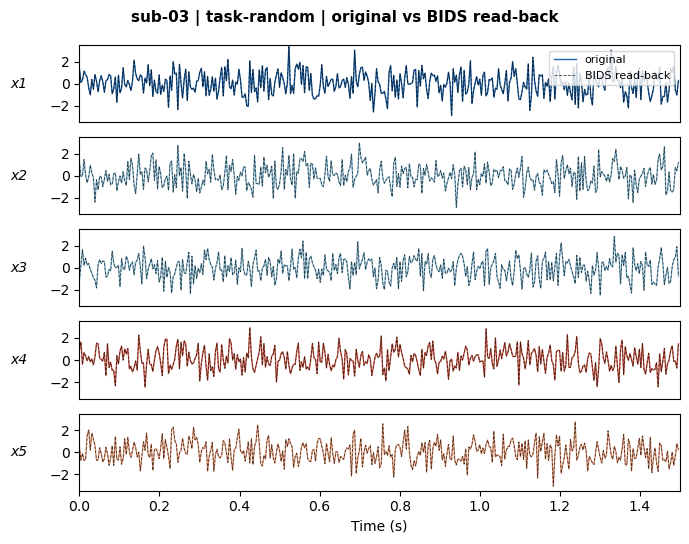

In [12]:
# Plot original vs recovered for sub-03
matplotlib.use('Agg')          # non-interactive, suppresses all plots
matplotlib.use('inline')       # restore inline display


T_SHOW = int(1.5 * FS)
t = np.arange(T_SHOW) / FS

fig, axes = plt.subplots(5, 1, figsize=(7.0, 5.5), sharex=True)
pal = ['#2166ac', '#92c5de', '#92c5de', '#d6604d', '#f4a582']

for i, ax in enumerate(axes):
    ax.plot(t, original[i, :T_SHOW],
            color=pal[i], linewidth=1.0, label='original')
    ax.plot(t, recovered[i, :T_SHOW],
            color='k', linewidth=0.6, linestyle='--', alpha=0.7, label='BIDS read-back')
    ax.set_ylabel(CH_NAMES[i], rotation=0, labelpad=22, va='center',
                  fontsize=10, fontstyle='italic')
    ax.set_ylim(-3.5, 3.5)
    ax.set_yticks([-2, 0, 2])
    ax.tick_params(bottom=(i == 4))

axes[0].legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Time (s)', fontsize=10)
axes[-1].set_xlim(0, T_SHOW / FS)
fig.suptitle(f'sub-{sub_check} | task-{TASK} | original vs BIDS read-back',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()